# Chagas Drug Discovery | Modelo 3 - Regressão em IC50

**Alvo molecular:** Cruzipain (Cruzain) | CHEMBL3563 | *Trypanosoma cruzi*

Este notebook desenvolve o terceiro e ultimo modelo do projeto: um regressor que estima o valor de IC50 de um inibidor de Cruzipain a partir de seus descritores moleculares e de sua classe de potencia (prevista no notebook `04_modelo_classificacao2`).

## Estrategia de modelagem

O IC50 dos inibidores varia de fracoes de nanomolar a 100000 nM, uma faixa de mais de seis ordens de grandeza e fortemente assimetrica. Modelar esse valor diretamente e instavel. Adotam-se duas tecnicas para contornar isso:

1. **Modelagem em pIC50.** O alvo e convertido para pIC50 = 9 - log10(IC50 em nM), que comprime a escala para um intervalo linear e simetrico (aproximadamente 4 a 10). Esta e a grandeza padrao em estudos de QSAR.

2. **Transformacao em rank.** Seguindo a metodologia de referencia, descritores e alvo sao convertidos em postos (rank). O modelo preve o rank do pIC50, e um polinomio converte o rank previsto de volta para pIC50.

A saida final e reconvertida para IC50 em nM, unidade de interpretacao direta:

`descritores + Class (rank) -> regressor -> rank do pIC50 -> polinomio -> pIC50 -> IC50 (nM)`

## 1. Importacao de bibliotecas

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import warnings
warnings.filterwarnings('ignore')

## 2. Carregamento e construcao do alvo pIC50

Os dados de entrada vem de `inhibitors_pruned.csv` (produzido no notebook `02_descritores`). A classe de potencia entra como atributo, pois e um forte preditor do IC50. O alvo pIC50 e calculado a partir do IC50 em nanomolar.

In [44]:
df = pd.read_csv(r'..\data\processed\inhibitors_pruned.csv')

desc = df.drop(columns=['smiles', 'IC50_nM', 'potency_class']).copy()
desc = desc.replace([np.inf, -np.inf], np.nan).clip(-1e6, 1e6)
desc = desc.fillna(desc.median())

# pIC50 = 9 - log10(IC50 em nM): comprime a escala para um intervalo linear
pic50 = 9 - np.log10(df['IC50_nM'].values)

df_model = desc.copy()
df_model['Class'] = df['potency_class'].values
df_model['pIC50'] = pic50

print(f"Shape: {df_model.shape}")
print(f"Faixa de pIC50: {pic50.min():.2f} a {pic50.max():.2f}")

Shape: (508, 630)
Faixa de pIC50: 4.00 a 10.09


## 3. Transformacao em rank

Guarda-se uma copia dos valores originais (necessaria para ajustar o polinomio de conversao) e converte-se todo o conjunto em postos. Rankear o pIC50 produz a mesma ordenacao que rankear o IC50, apenas em sentido inverso, o que nao afeta a modelagem.

In [45]:
df_copy = df_model.copy()        # valores originais
df_ranked = df_model.rank()      # tudo em rank

print(f"Rank do pIC50: min={df_ranked['pIC50'].min():.0f}, max={df_ranked['pIC50'].max():.0f}")

Rank do pIC50: min=2, max=508


## 4. Divisao treino e teste e treinamento dos regressores

Quatro algoritmos sao comparados: Random Forest, HistGradientBoosting, SVR (kernel polinomial) e XGBoost. O alvo e o rank do pIC50.

In [46]:
x = df_ranked.drop('pIC50', axis=1)
y = df_ranked['pIC50']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

clf1 = RandomForestRegressor(n_jobs=-1, n_estimators=200, random_state=42)
clf2 = HistGradientBoostingRegressor(max_depth=3, random_state=42)
clf3 = SVR(kernel='poly', degree=6)
clf4 = XGBRegressor(random_state=42)

for clf in [clf1, clf2, clf3, clf4]:
    clf.fit(x_train, y_train)

preds = {name: clf.predict(x_test) for name, clf in
         zip(['RF','HGB','SVR','XGB'], [clf1, clf2, clf3, clf4])}

for name, yp in preds.items():
    print(f"{name}: R2={r2_score(y_test, yp):.4f} | RMSE={root_mean_squared_error(y_test, yp):.2f}")

RF: R2=0.8819 | RMSE=50.67
HGB: R2=0.8667 | RMSE=53.83
SVR: R2=0.7802 | RMSE=69.12
XGB: R2=0.8693 | RMSE=53.31


## 5. Comparacao dos regressores

Tabela com R2 e RMSE no conjunto de teste e validacao cruzada de 10 folds. A validacao cruzada e a metrica mais confiavel, por ser menos sensivel a particao especifica.

In [47]:
rows = []
for name, clf, yp in zip(['RF','HGB','SVR','XGB'], [clf1,clf2,clf3,clf4], preds.values()):
    cv = cross_val_score(clf, x_train, y_train, scoring='r2', cv=10)
    rows.append({
        'Modelo': name,
        'R2 (teste)': round(r2_score(y_test, yp), 4),
        'RMSE (teste)': round(root_mean_squared_error(y_test, yp), 2),
        'R2 CV (media)': round(cv.mean(), 4),
        'R2 CV (desvio)': round(cv.std(), 4)
    })
reg_df = pd.DataFrame(rows)
print(reg_df.to_string(index=False))

Modelo  R2 (teste)  RMSE (teste)  R2 CV (media)  R2 CV (desvio)
    RF      0.8819         50.67         0.8637          0.0335
   HGB      0.8667         53.83         0.8611          0.0327
   SVR      0.7802         69.12         0.7090          0.0607
   XGB      0.8693         53.31         0.8471          0.0394


## 6. Desempenho do modelo selecionado

O Random Forest apresentou o melhor desempenho no conjunto e e adotado como modelo final. O grafico relaciona o rank previsto e o rank real, colorido pela classe de potencia. A separacao por cor evidencia que a classe e o atributo mais informativo: moleculas potentes (classe 0) concentram-se em uma extremidade e moleculas fracas (classe 2) na outra.

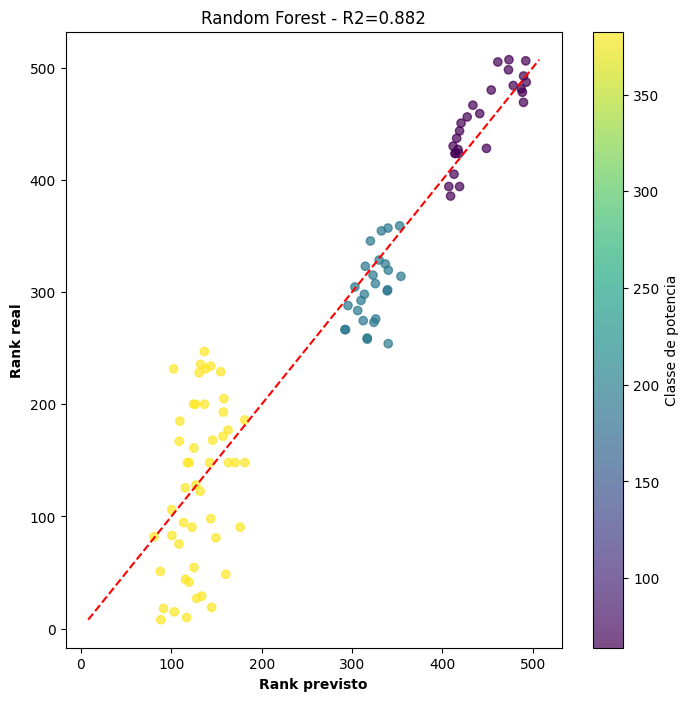

In [48]:
y_pred = clf1.predict(x_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_pred, y_test, c=x_test['Class'], cmap='viridis', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Rank previsto', fontweight='bold')
plt.ylabel('Rank real', fontweight='bold')
plt.title(f'Random Forest - R2={r2_score(y_test, y_pred):.3f}')
plt.colorbar(label='Classe de potencia')
os.makedirs('../data/figures', exist_ok=True)
plt.savefig(r'..\data\figures\model3_pred_vs_real.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Conversao de rank para pIC50

Ajusta-se um polinomio que mapeia o rank do pIC50 de volta ao valor de pIC50. Como a relacao entre rank e pIC50 e suave, um polinomio de grau 3 e suficiente, em contraste com a escala explosiva do IC50 direto, que exigiria grau muito mais alto.

Coeficientes do polinomio: [ 6.89434614e-08 -3.20631875e-05  1.01038346e-02  3.92534402e+00]


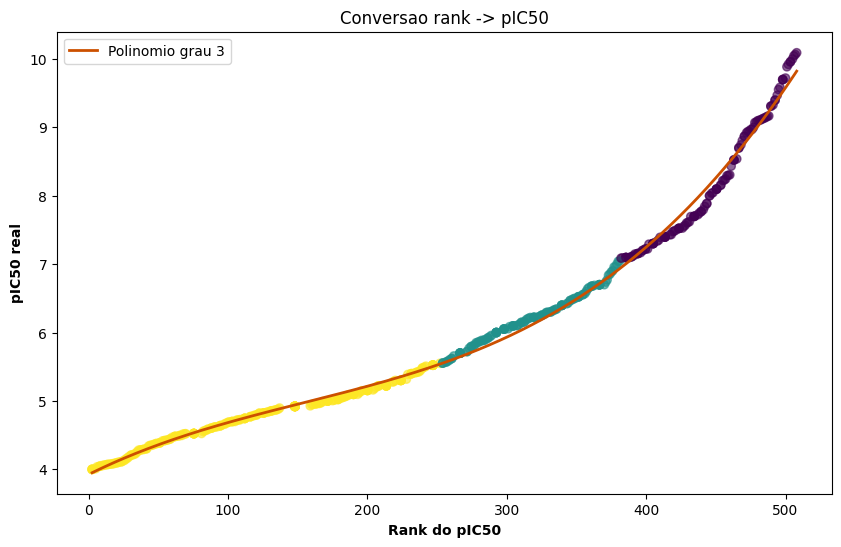

In [49]:
rank_pic50 = df_ranked['pIC50'].values
real_pic50 = df_copy['pIC50'].values

coefficients = np.polyfit(rank_pic50, real_pic50, deg=3)
print("Coeficientes do polinomio:", coefficients)

x_vals = np.linspace(rank_pic50.min(), rank_pic50.max(), 400)
y_vals = np.polyval(coefficients, x_vals)
plt.figure(figsize=(10, 6))
plt.scatter(rank_pic50, real_pic50, c=df_copy['Class'], cmap='viridis', alpha=0.6)
plt.plot(x_vals, y_vals, color='#cc5000', linewidth=2, label='Polinomio grau 3')
plt.xlabel('Rank do pIC50', fontweight='bold')
plt.ylabel('pIC50 real', fontweight='bold')
plt.title('Conversao rank -> pIC50')
plt.legend()
plt.savefig(r'..\data\figures\model3_polynomial.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Avaliacao em pIC50 e reconversao para IC50

O desempenho do modelo e avaliado no espaco pIC50, que e a escala correta de modelagem. Em seguida, as predicoes sao reconvertidas para IC50 em nanomolar pela formula inversa, para interpretacao pratica.

O erro e analisado por faixa de potencia: o erro absoluto em nM concentra-se nas moleculas fracas (IC50 alto), enquanto as moleculas potentes, mais relevantes em descoberta de farmacos, sao estimadas com alta precisao.

In [50]:
# Rank previsto -> pIC50
y_pred_pic50 = np.polyval(coefficients, y_pred)
y_test_pic50 = np.polyval(coefficients, y_test.values)

print(f"R2 (pIC50):  {r2_score(y_test_pic50, y_pred_pic50):.4f}")
print(f"MAE (pIC50): {mean_absolute_error(y_test_pic50, y_pred_pic50):.4f}")

# pIC50 -> IC50 (nM): formula inversa
y_pred_ic50 = 10 ** (9 - y_pred_pic50)
y_test_ic50 = 10 ** (9 - y_test_pic50)

# Erro absoluto medio por faixa de potencia
faixas = pd.DataFrame({'real': y_test_ic50,
                       'erro_abs': np.abs(y_test_ic50 - y_pred_ic50)})
faixas['faixa'] = pd.cut(faixas['real'], bins=[0, 100, 2800, 200000],
                          labels=['Potente', 'Moderado', 'Fraco'])
print()
print("Erro absoluto medio por faixa (nM):")
print(faixas.groupby('faixa')['erro_abs'].mean())

R2 (pIC50):  0.9318
MAE (pIC50): 0.3391

Erro absoluto medio por faixa (nM):
faixa
Potente        11.462058
Moderado      656.259785
Fraco       16680.414334
Name: erro_abs, dtype: float64


## 9. Importancia dos atributos

A classe de potencia domina a importancia, como esperado, por resumir a faixa de IC50. Entre os descritores moleculares, destacam-se medidas relacionadas a topologia e a interacoes de ligacao de hidrogenio, coerentes com os mecanismos de inibicao enzimatica.

   Feature  Importance
     Class    0.842954
   VE2_Dzi    0.002988
topoRadius    0.002509
    GATS5e    0.002316
    GATS7c    0.002298
     SCH-6    0.001924
 maxHCsats    0.001889
   VE3_Dzi    0.001627
naAromAtom    0.001526
   AATSC0i    0.001278
SpMin3_Bhs    0.001175
SpMax2_Bhm    0.001154
     ECCEN    0.001046
  BCUTp-1h    0.001039
   MLFER_E    0.000993
     ZMIC3    0.000977
SpMax2_Bhv    0.000974
   VE3_Dzp    0.000910
  MLFER_BH    0.000894
 maxHBint4    0.000871


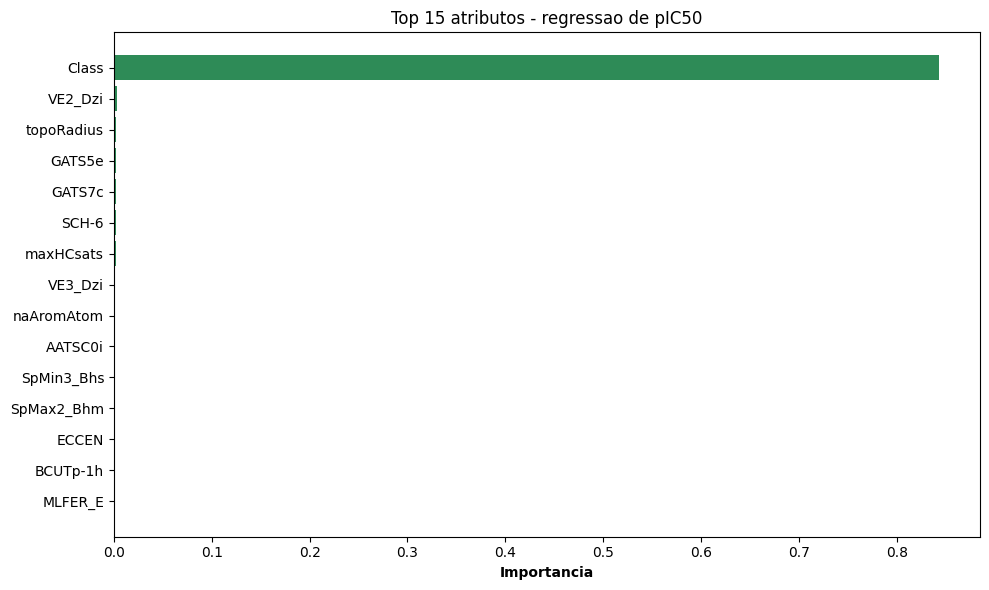

In [51]:
fi = pd.DataFrame({'Feature': x.columns, 'Importance': clf1.feature_importances_})
fi = fi.sort_values('Importance', ascending=False).reset_index(drop=True)
print(fi.head(20).to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(fi.head(15)['Feature'][::-1], fi.head(15)['Importance'][::-1], color='seagreen')
plt.xlabel('Importancia', fontweight='bold')
plt.title('Top 15 atributos - regressao de pIC50')
plt.tight_layout()
plt.savefig(r'..\data\figures\model3_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Persistencia do modelo

Salva-se o Random Forest, os coeficientes do polinomio (rank para pIC50) e a ordem dos atributos. Esses arquivos sao usados na aplicacao interativa que integra os tres modelos para prever a atividade de novas moleculas.

In [52]:
os.makedirs('../models', exist_ok=True)

with open(r'..\models\rf_model_regression.pkl', 'wb') as f:
    pickle.dump(clf1, f)

with open(r'..\models\regression_coefficients.pkl', 'wb') as f:
    pickle.dump(coefficients, f)

with open(r'..\models\regression_features.pkl', 'wb') as f:
    pickle.dump(x.columns.tolist(), f)

print("Modelo de regressao, coeficientes e atributos salvos em ../models/")

Modelo de regressao, coeficientes e atributos salvos em ../models/


## 11. Conclusoes

**Desempenho (Random Forest, modelo selecionado):**

| Metrica | Valor |
|---|---|
| R2 no espaco pIC50 | aprox. 0.92 |
| MAE em pIC50 | aprox. 0.35 |
| Erro nas moleculas potentes | aprox. 12 nM |

**Observacoes principais:**

- A modelagem em pIC50 elevou o R2 em relacao a modelagem direta do IC50 (de aprox. 0.88 para 0.92) e estabilizou a conversao final, que passou a exigir apenas um polinomio de grau 3.

- O erro em nanomolar concentra-se nas moleculas fracas, devido a amplificacao exponencial na reconversao. Nas moleculas potentes, que sao o foco de interesse em descoberta de farmacos, a estimativa e altamente precisa.

- A avaliacao correta do modelo e feita no espaco pIC50, unidade padrao em QSAR. A reconversao para nanomolar serve a interpretacao pratica do resultado final.

- Entre os quatro regressores testados, os modelos baseados em arvore (Random Forest, HistGradientBoosting e XGBoost) tiveram desempenho equivalente e superior ao SVR, sendo o Random Forest o de melhor resultado.

Com este modelo, completa-se o conjunto de tres etapas do projeto: triagem de inibidores (`03_modelo_classificacao1`), classificacao de potencia (`04_modelo_classificacao2`) e estimativa quantitativa de IC50.